# Segunda parte : Analisis

## Paso 1: Esta celda importa Pandas y carga el dataset

In [1]:
import pandas as pd
df = pd.read_csv('dataset_limpio2.csv')

# Verificar las dimensiones y las primeras filas
print(f"El dataset contiene {df.shape[0]} filas y {df.shape[1]} columnas.")
display(df.head(3))

El dataset contiene 22329 filas y 20 columnas.


,año,no_doc,universidad,tipo,especialidad/subespecialidad,modalidad,serum,sncds,1er_niv,5to_sup,prom_pre,enam,examen,not_final,ingresó_si/no,universidad_(ingreso),especialidad/subespecialidad_(ingreso),sede_(ingreso),total_bonificacion,nota_cv
0,2023,73815684,CONAREME,Especialidad,ANATOMIA PATOLOGICA,Libre,10.0,0.0,0.0,0.0,1.970,1.5,60.4,73.870,SI,UNMSM,ANATOMIA PATOLOGICA,Hospital Nacional Edgardo Rebagliati Martins,10.0,13.470
1,2023,71701411,CONAREME,Especialidad,ANATOMIA PATOLOGICA,Libre,10.0,0.0,0.0,0.0,1.973,2.0,57.2,71.173,SI,UNMSM,ANATOMIA PATOLOGICA,Hospital Nacional Edgardo Rebagliati Martins,10.0,13.973
2,2023,46024669,CONAREME,Especialidad,ANATOMIA PATOLOGICA,Libre,10.0,0.0,0.0,1.0,1.893,1.0,56.0,69.893,SI,URP,ANATOMIA PATOLOGICA,Hospital Nacional Edgardo Rebagliati Martins,11.0,13.893


## Paso 2: Generación de Resúmenes Estadísticos Matemáticos

### calculamos las medidas de tendencia central y dispersión pura para las variables críticas.

In [2]:
# 1. Definir las variables numéricas de interés
columnas_numericas = ['examen', 'not_final', 'nota_cv']

print("--- 1. Medidas de Tendencia Central y Dispersión (General) ---")
# Generamos el resumen estadístico general (media, mediana, desviación estándar, rangos)
resumen_estadistico = df[columnas_numericas].describe().round(2)
display(resumen_estadistico)

print("\n--- 2. Resumen Estadístico Agrupado por Condición de Ingreso ---")
# Comparamos matemáticamente los promedios de los que ingresaron vs los que no
resumen_ingreso = df.groupby('ingresó_si/no')[columnas_numericas].mean().round(2)
display(resumen_ingreso)

# 3. Calculamos la Varianza matemática de las notas finales
print("\n--- 3. Varianza de la Nota Final ---")
varianza_notas = df['not_final'].var()
print(f"La varianza poblacional de la Nota Final es: {varianza_notas:.2f}")

--- 1. Medidas de Tendencia Central y Dispersión (General) ---


,examen,not_final,nota_cv
count,22102.00,22102.00,22102.00
mean,47.56,59.54,11.98
std,8.55,9.69,2.41
min,8.00,14.98,0.00
25%,41.20,52.62,10.75
50%,47.60,59.53,12.63
75%,54.00,66.71,13.45
max,77.60,91.10,20.28



--- 2. Resumen Estadístico Agrupado por Condición de Ingreso ---


,examen,not_final,nota_cv
ingresó_si/no,,,
NO,45.91,57.64,11.73
SI,50.05,62.40,12.35



--- 3. Varianza de la Nota Final ---
La varianza poblacional de la Nota Final es: 93.93


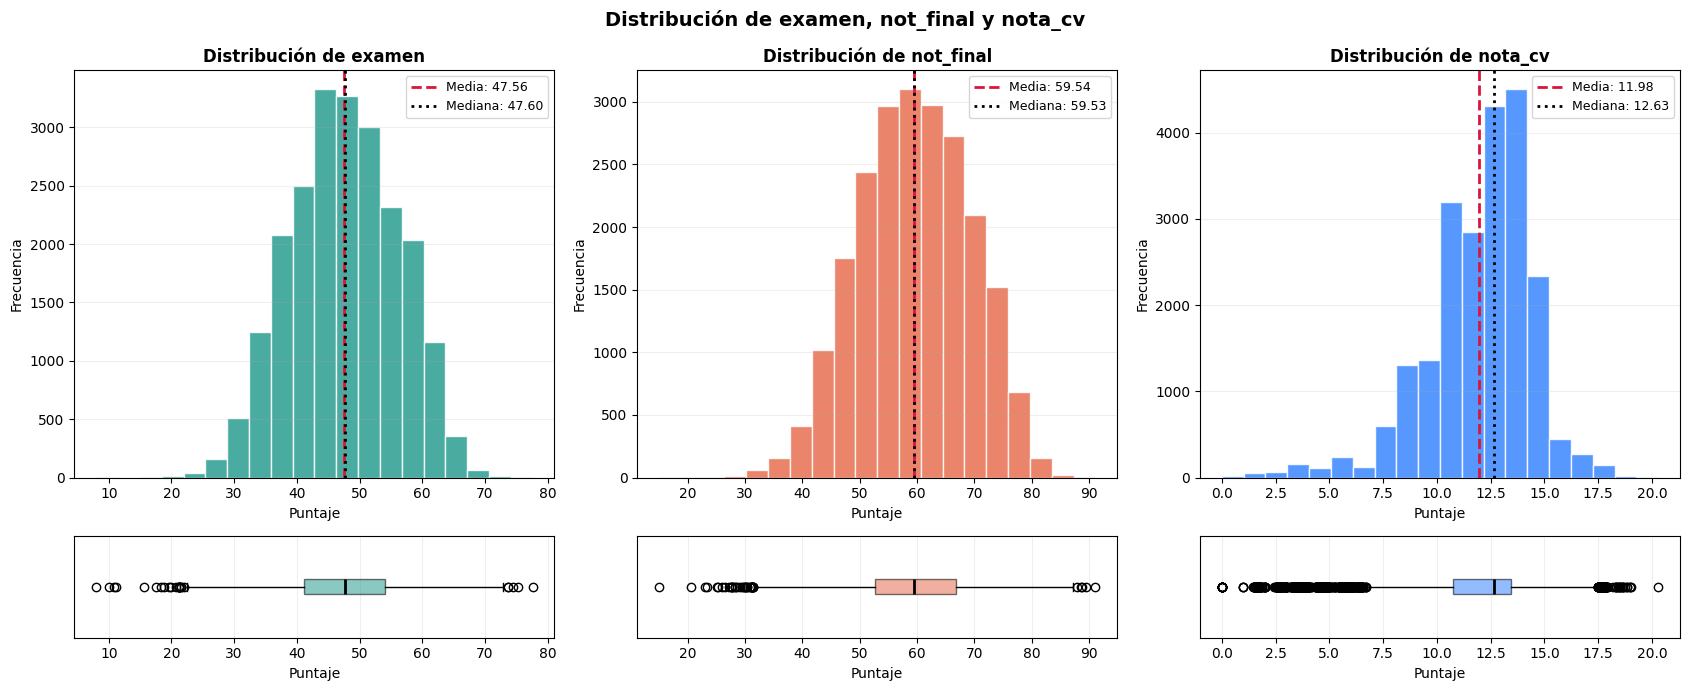

In [4]:
import matplotlib.pyplot as plt

# Variables del Paso 2
columnas = ['examen', 'not_final', 'nota_cv']

# Validación rápida por si falta alguna columna
faltantes = [c for c in columnas if c not in df.columns]
if faltantes:
    raise ValueError(f"Faltan estas columnas en el DataFrame: {faltantes}")

# Figura: arriba histogramas, abajo boxplots (para ver dispersión y outliers)
fig, axes = plt.subplots(
    2, 3, figsize=(17, 7),
    gridspec_kw={'height_ratios': [4, 1]}
)

colores = ['#2A9D8F', '#E76F51', '#3A86FF']

for i, col in enumerate(columnas):
    serie = df[col].dropna()

    # Histograma
    axes[0, i].hist(
        serie, bins=20, color=colores[i], alpha=0.85, edgecolor='white'
    )
    media = serie.mean()
    mediana = serie.median()

    axes[0, i].axvline(media, color='crimson', linestyle='--', linewidth=2, label=f"Media: {media:.2f}")
    axes[0, i].axvline(mediana, color='black', linestyle=':', linewidth=2, label=f"Mediana: {mediana:.2f}")
    axes[0, i].set_title(f"Distribución de {col}", fontsize=12, fontweight='bold')
    axes[0, i].set_xlabel("Puntaje")
    axes[0, i].set_ylabel("Frecuencia")
    axes[0, i].legend(fontsize=9)
    axes[0, i].grid(axis='y', alpha=0.2)

    # Boxplot horizontal
    axes[1, i].boxplot(
        serie, vert=False, patch_artist=True,
        boxprops=dict(facecolor=colores[i], alpha=0.55),
        medianprops=dict(color='black', linewidth=2)
    )
    axes[1, i].set_xlabel("Puntaje")
    axes[1, i].set_yticks([])
    axes[1, i].grid(axis='x', alpha=0.2)

plt.suptitle("Distribución de examen, not_final y nota_cv", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Paso 3: Conclusión


Diagrama de Examen (Verde): Distribución simétrica (normal). Las notas forman una campana perfecta y equilibrada alrededor de los 47.6 puntos. Hay tanto notas excepcionalmente altas como excepcionalmente bajas (los puntos fuera de los bigotes en ambos lados).

Diagrama de Not_final (Naranja): Distribución simétrica (normal). Tiene el mismo comportamiento que el examen, pero con las notas centradas alrededor de los 60 puntos. Los bigotes son parejos, lo que indica una dispersión normal hacia ambos lados.

Diagrama de Nota_cv (Azul): Distribución asimétrica negativa (sesgada a la izquierda). La mayoría de los estudiantes sacó notas altas, agrupándose a la derecha. Por eso, el bigote derecho es muy cortito, mientras que el izquierdo es muy largo y está lleno de valores atípicos (estudiantes con notas inusualmente bajas).

La depuración del dataset fortaleció la calidad del análisis: se conservaron 22,329 registros útiles, se redujo la base de 26 a 20 variables, se eliminaron datos personales y se construyeron correctamente variables clave como bonificación total y nota CV. Aunque persisten faltantes importantes en ENAM, el conjunto final quedó suficientemente robusto para evaluar el rendimiento académico de los postulantes.

En los resultados, los ingresantes muestran mejores promedios en todas las métricas académicas, y la variabilidad de la nota final confirma que existen diferencias reales de desempeño entre postulantes. Además, examen presenta la asociación más alta con nota final, seguido por ENAM y nota CV, mientras que bonificación total tiene una relación positiva menor; en conjunto, un mejor rendimiento académico integral se vincula con mayor probabilidad de ingreso, sin implicar causalidad directa.